# 10 - SARIMAX benchmark products

This notebook reuses the existing project `SARIMAXModel` and the existing project feature engineering logic, adapted to the official three-product M5 benchmark.

Benchmark products:
- `FOODS_3_228_CA_1_validation` (`high_demand_stable`)
- `FOODS_2_044_CA_3_validation` (`intermittent`)
- `HOBBIES_1_133_CA_4_validation` (`low_volume`)

Official protocol:
- `MAX_DAYS = 365`
- `CONTEXT_LENGTH = 28`
- `VAL_DAYS = 28`
- `TEST_DAYS = 28`
- train = `309`, validation = `28`, fit = `337`, test = final `28`

Note: SARIMAX does not use context windows the same way as neural models. For fairness, we keep the exact same final horizon and chronological split.

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == 'gnn_model_comparison':
    ROOT = ROOT.parents[1]
elif ROOT.name == 'notebooks':
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'reports' / 'gnn_benchmarks' / 'sarimax_benchmark_products'
OUT_DIR


WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/sarimax_benchmark_products')

## Existing project code reused

- `src/models/sarimax_model.py`
- feature engineering adapted from `src/experiments/run_sarimax_benchmark.py`
- benchmark evaluation style aligned with the newer benchmark notebooks

Adaptation note:
- rolling features were kept conceptually the same, but shifted to avoid same-day target leakage


In [3]:
from src.experiments.run_sarimax_benchmark_products import main

main()


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

[RUN] FOODS_3_228_CA_1_validation | order=(1, 0, 1) | seasonal=(0, 1, 1, 7) | mae=2.836876 | vr=0.800717 | flat=non-flat


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

[RUN] FOODS_2_044_CA_3_validation | order=(1, 0, 1) | seasonal=(1, 0, 1, 7) | mae=1.210873 | vr=0.270567 | flat=non-flat


c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\braya\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optim

[RUN] HOBBIES_1_133_CA_4_validation | order=(1, 0, 1) | seasonal=(0, 1, 1, 7) | mae=0.000000 | vr=0.000000 | flat=flat
[OK] Saved metrics -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\sarimax_benchmark_products\metrics.csv
[OK] Saved training summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\sarimax_benchmark_products\training_summary.csv
[OK] Saved summary -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\sarimax_benchmark_products\summary.csv
[OK] Saved predictions -> C:\Users\braya\Documents\Research\aurex-demand-forecasting-main\reports\gnn_benchmarks\sarimax_benchmark_products\predictions.csv


In [4]:
import pandas as pd

training_summary_df = pd.read_csv(OUT_DIR / 'training_summary.csv')
metrics_df = pd.read_csv(OUT_DIR / 'metrics.csv')
summary_df = pd.read_csv(OUT_DIR / 'summary.csv')

training_summary_df


,series_id,benchmark_label,model,best_order,best_seasonal_order,upper_cap,zero_rate_fit,final_loss,context_length,train_days,fit_days
0,FOODS_3_228_CA_1_validation,high_demand_stable,SARIMAX,"(1, 0, 1)","(0, 1, 1, 7)",35.207715,0.011869,NaN,28,309,337
1,FOODS_2_044_CA_3_validation,intermittent,SARIMAX,"(1, 0, 1)","(1, 0, 1, 7)",6.000000,0.617211,NaN,28,309,337
2,HOBBIES_1_133_CA_4_validation,low_volume,SARIMAX,"(1, 0, 1)","(0, 1, 1, 7)",1.500000,0.943620,NaN,28,309,337


In [5]:
summary_df


,series_id,benchmark_label,final_loss,mae,rmse,pred_std,real_std,variance_ratio,trend_correlation,direction_accuracy,shape_similarity,peak_detection_rate,flat_nonflat
0,FOODS_3_228_CA_1_validation,high_demand_stable,NaN,2.836876,3.759589,2.227450,2.781820,0.800717,0.522383,0.481481,0.718502,1.0,non-flat
1,FOODS_2_044_CA_3_validation,intermittent,NaN,1.210873,1.587210,0.394179,1.456863,0.270567,-0.288062,0.444444,0.674077,0.6,non-flat
2,HOBBIES_1_133_CA_4_validation,low_volume,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,1.000000,1.0,flat


WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/sarimax_benchmark_products/figures/high_demand_stable_FOODS_3_228_CA_1_validation_real_vs_predicted.png')

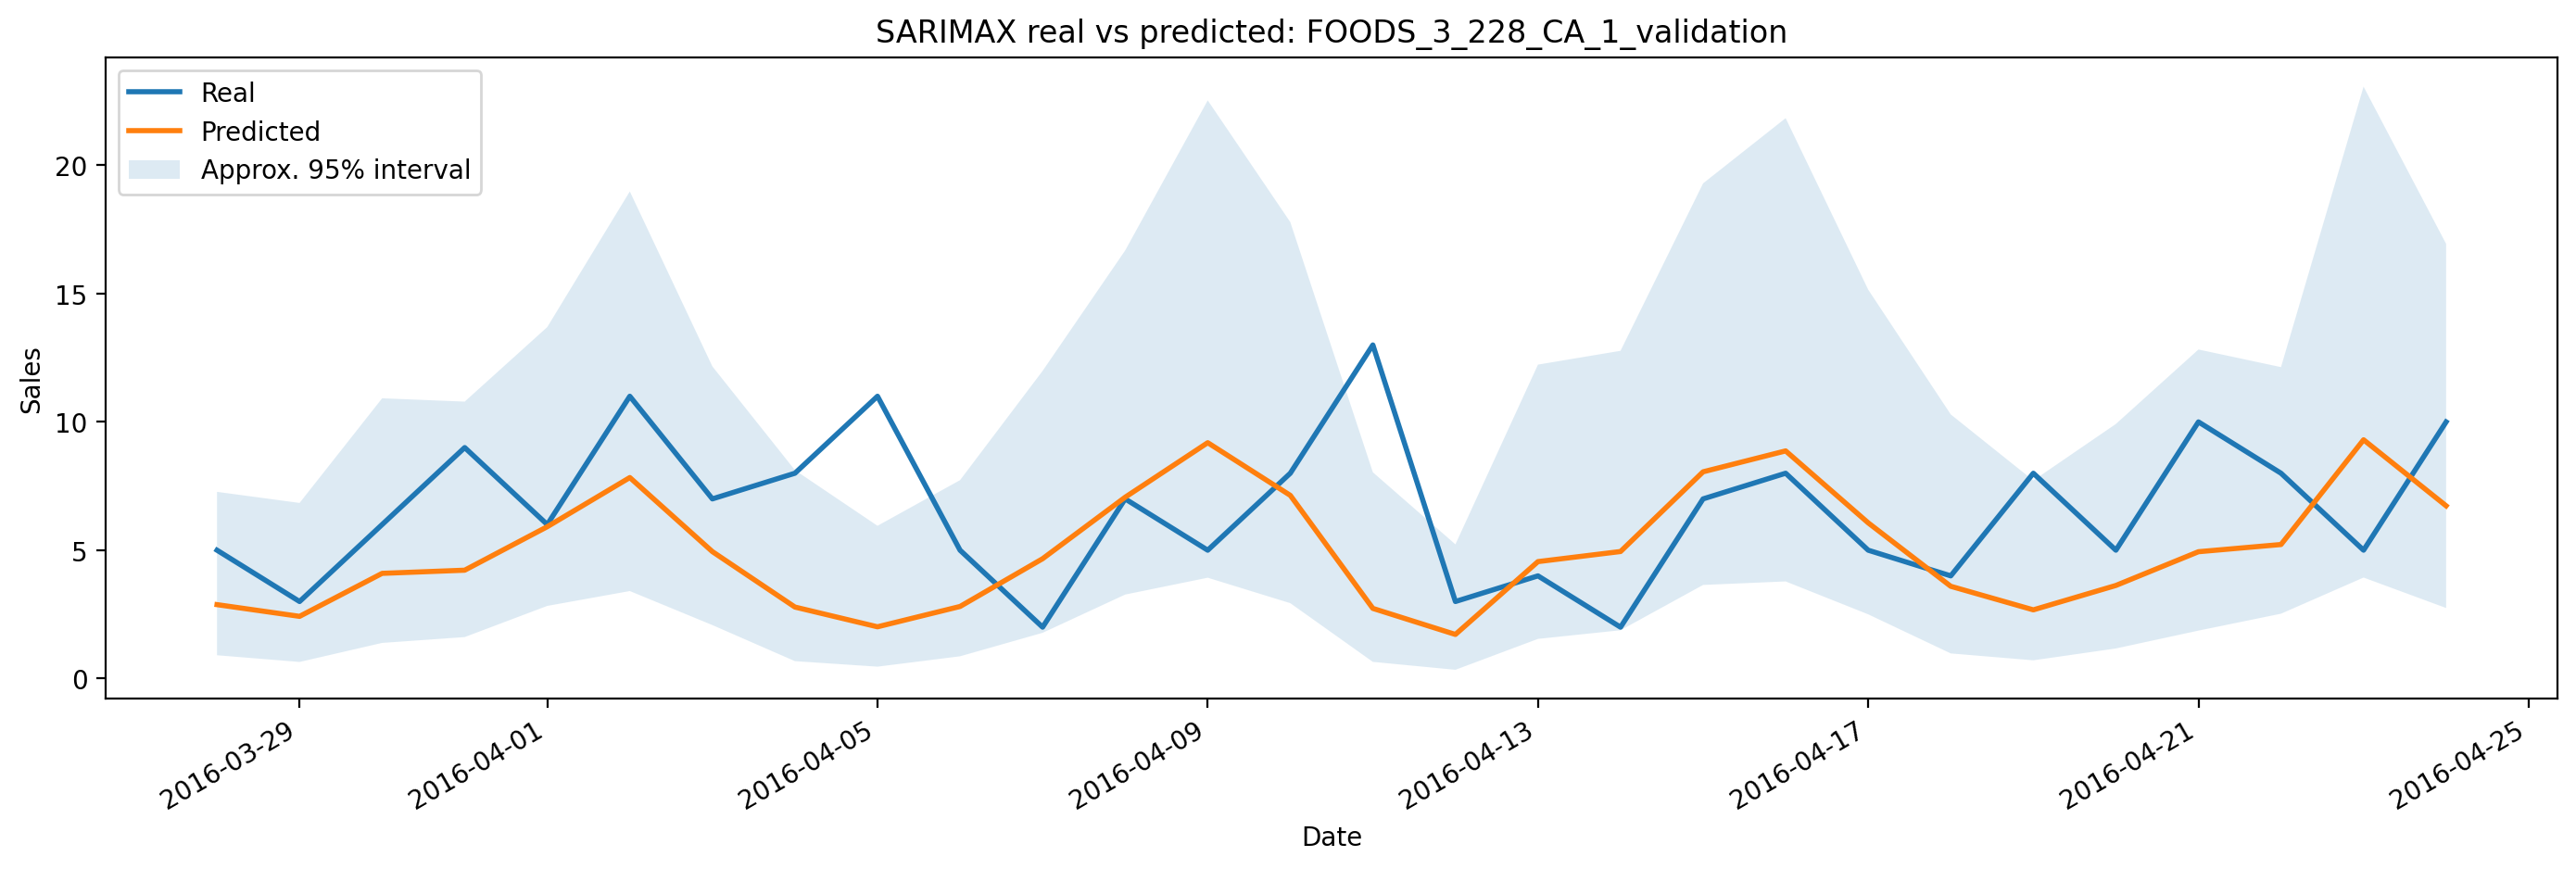

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/sarimax_benchmark_products/figures/intermittent_FOODS_2_044_CA_3_validation_real_vs_predicted.png')

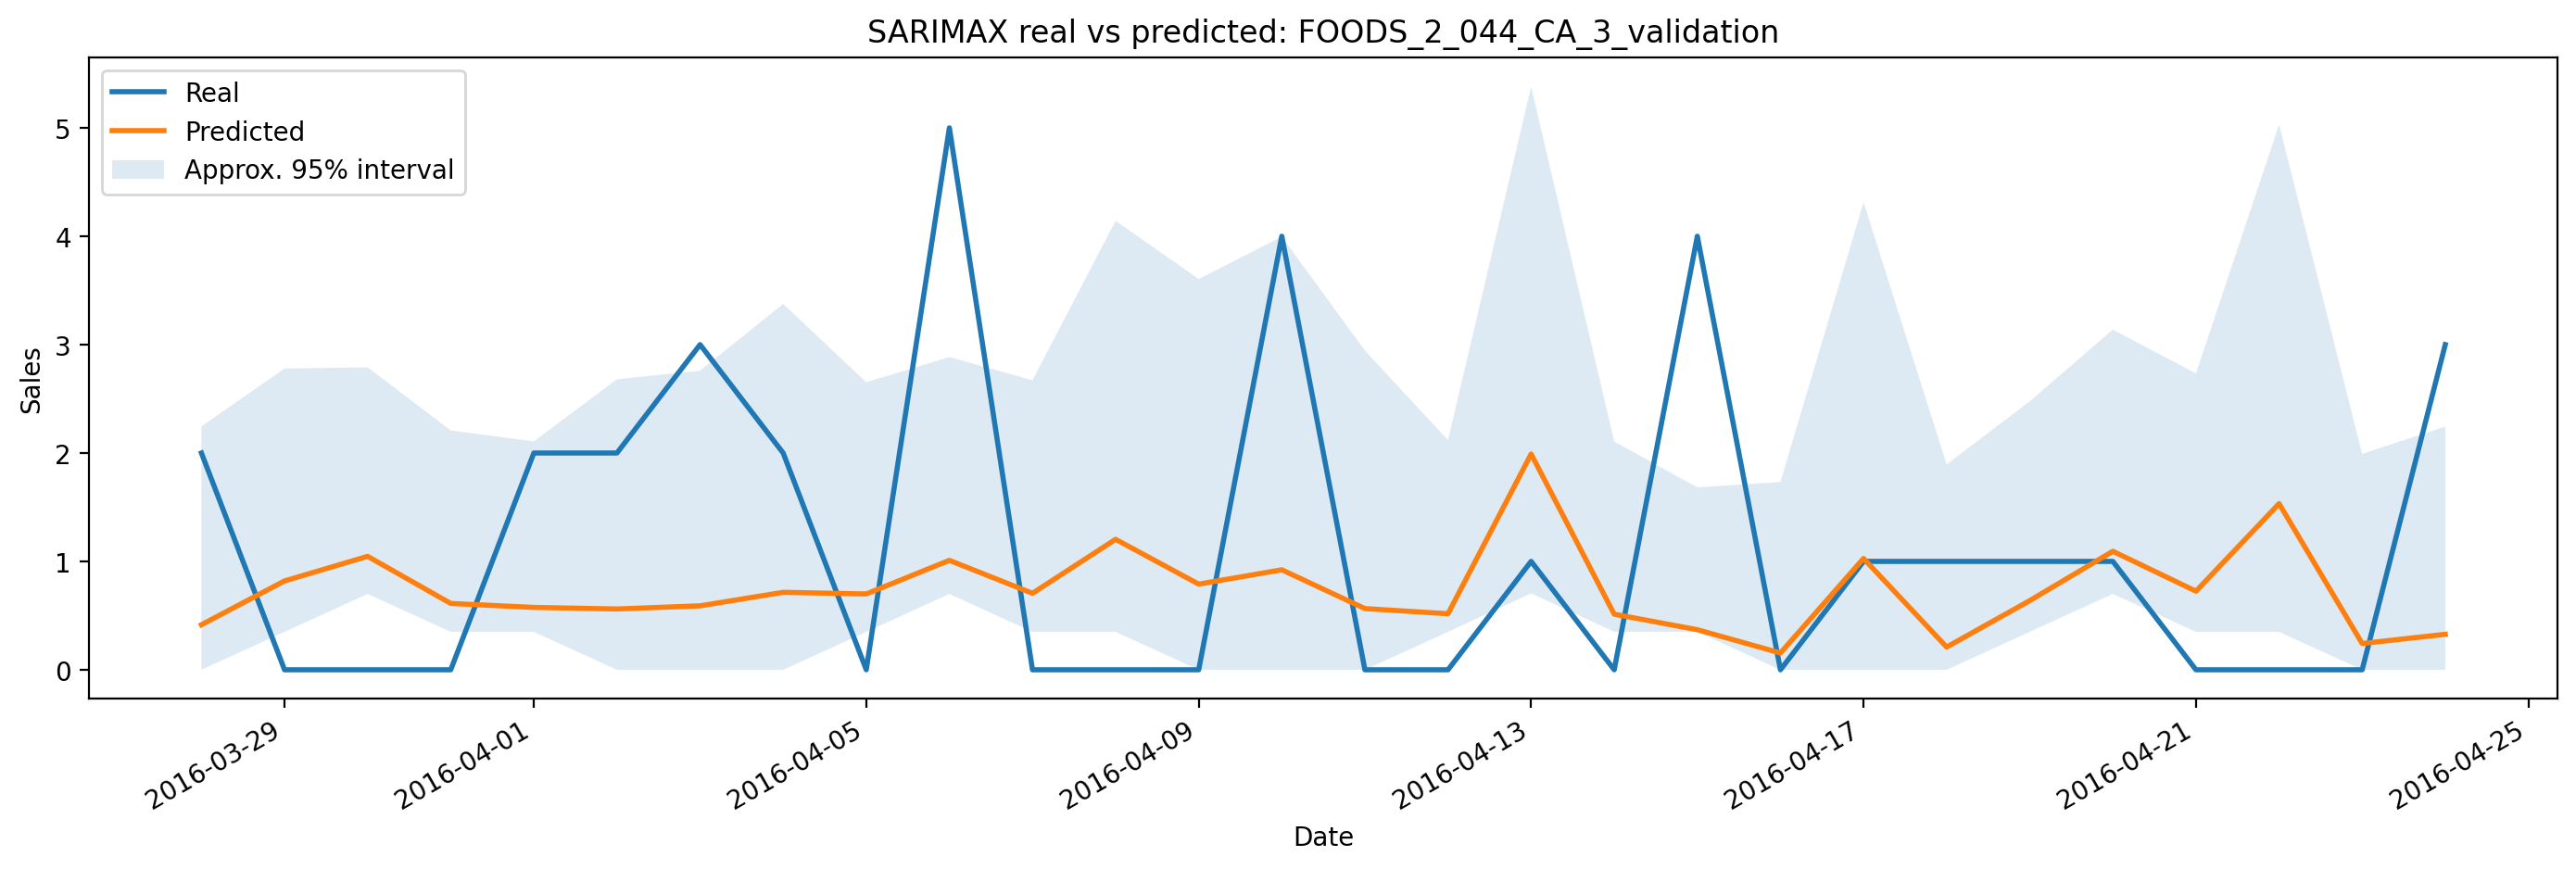

WindowsPath('c:/Users/braya/Documents/Research/aurex-demand-forecasting-main/reports/gnn_benchmarks/sarimax_benchmark_products/figures/low_volume_HOBBIES_1_133_CA_4_validation_real_vs_predicted.png')

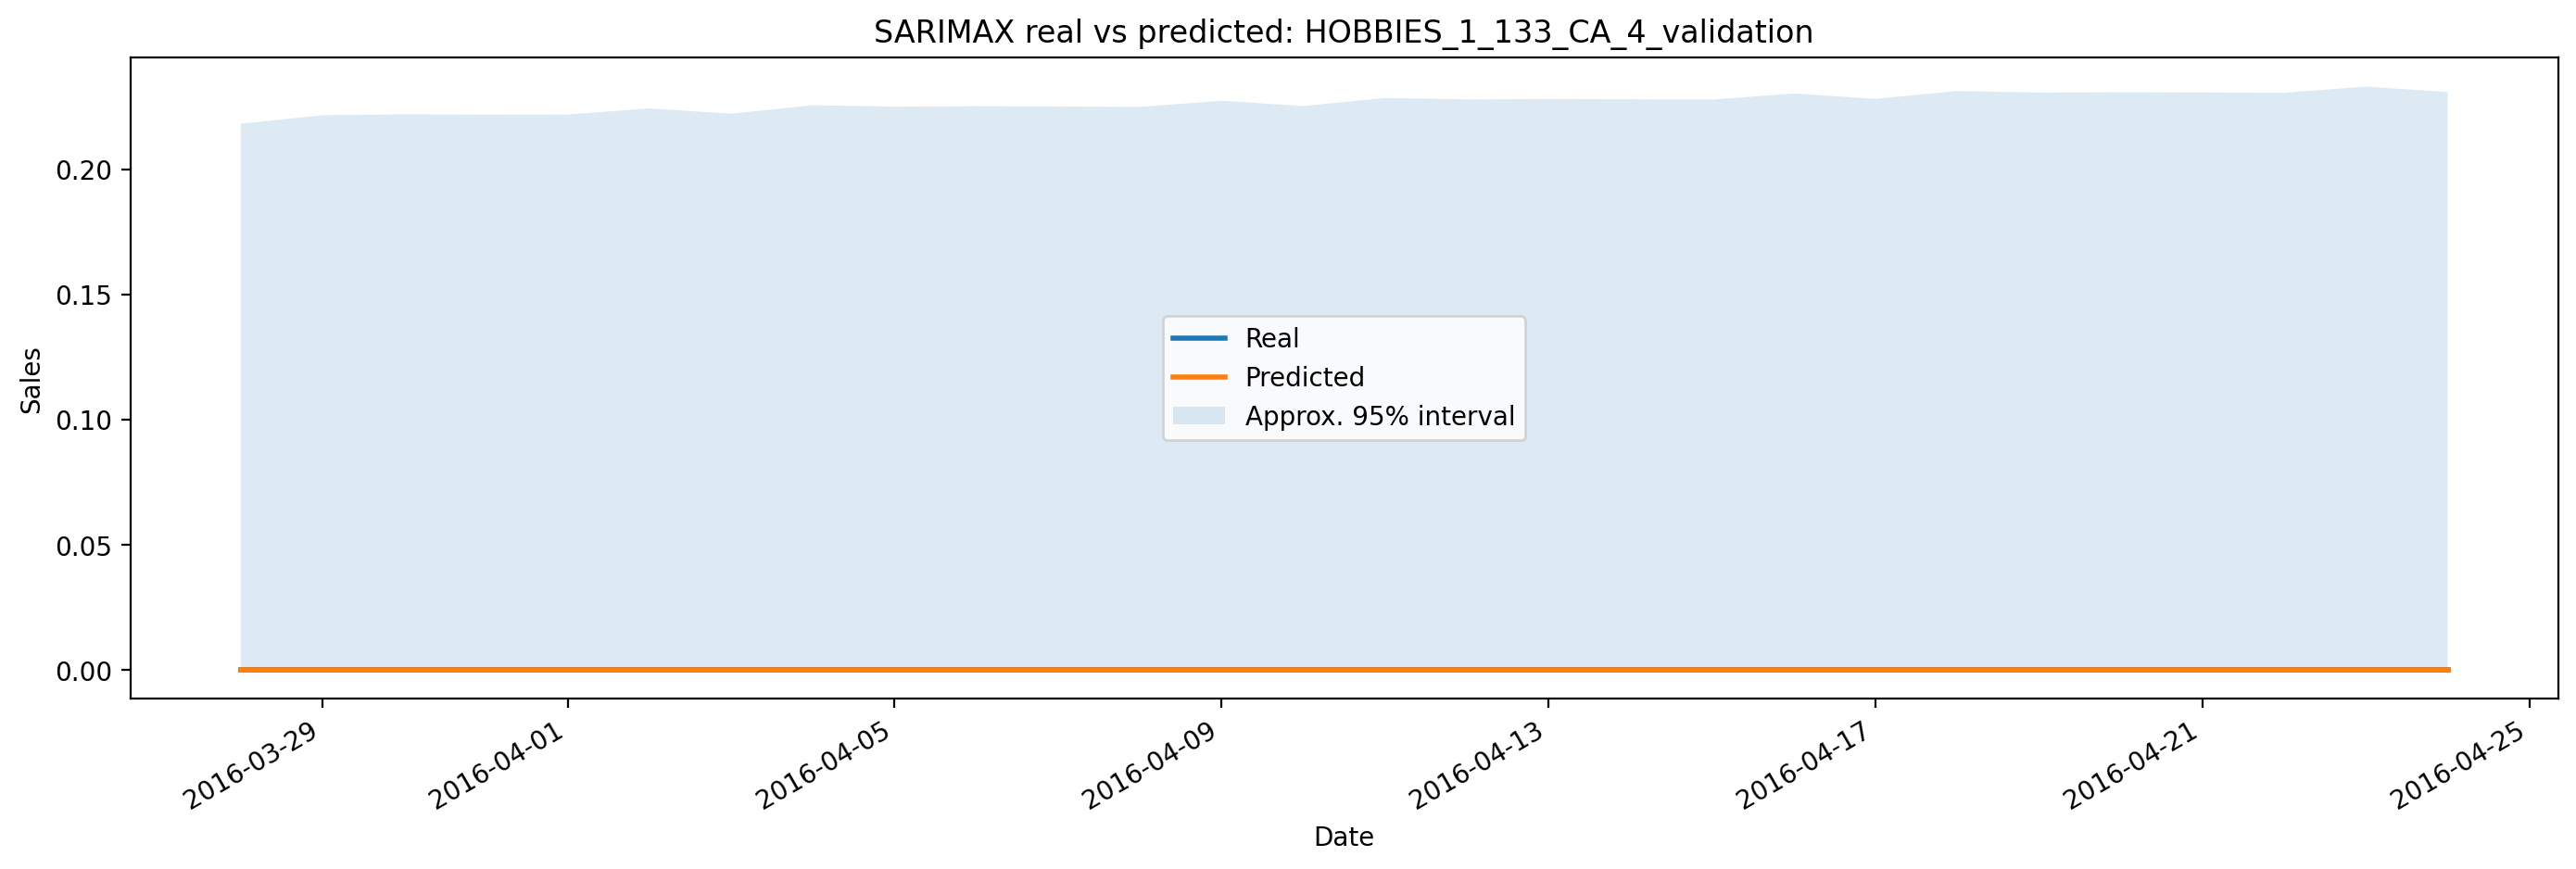

In [6]:
from IPython.display import Image, display

for label, series_id in [
    ('high_demand_stable', 'FOODS_3_228_CA_1_validation'),
    ('intermittent', 'FOODS_2_044_CA_3_validation'),
    ('low_volume', 'HOBBIES_1_133_CA_4_validation'),
]:
    path = OUT_DIR / 'figures' / f'{label}_{series_id}_real_vs_predicted.png'
    display(path)
    display(Image(filename=str(path)))
